In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
os.makedirs('../reports/charts', exist_ok=True)

print("Libraries loaded!")

Libraries loaded!


In [4]:
# Load data
nav = pd.read_csv('../data/processed/02_nav_history_clean.csv', parse_dates=['date'])
funds = pd.read_csv('../data/processed/01_fund_master_clean.csv')
transactions = pd.read_csv('../data/processed/08_investor_transactions_clean.csv', 
                           parse_dates=['transaction_date'])
portfolio = pd.read_csv('../data/processed/09_portfolio_holdings_clean.csv')
scorecard = pd.read_csv('../data/processed/fund_scorecard.csv')

# Compute daily returns for all funds
nav = nav.sort_values(['amfi_code', 'date']).reset_index(drop=True)
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

print("Data loaded!")
print("NAV:", nav.shape)
print("Funds:", funds.shape)
print("Transactions:", transactions.shape)
print("Portfolio:", portfolio.shape)
print("Scorecard:", scorecard.shape)

Data loaded!
NAV: (64320, 4)
Funds: (40, 15)
Transactions: (32778, 13)
Portfolio: (322, 8)
Scorecard: (40, 14)


In [5]:
# Task 1 — VaR and CVaR for all 40 funds

var_results = []

for code in nav['amfi_code'].unique():
    fund_returns = nav[nav['amfi_code'] == code]['daily_return'].dropna()
    
    # VaR (95%) — 5th percentile of return distribution
    var_95 = np.percentile(fund_returns, 5)
    
    # CVaR — mean of all returns below VaR threshold
    cvar_95 = fund_returns[fund_returns <= var_95].mean()
    
    var_results.append({
        'amfi_code': code,
        'var_95_pct': round(var_95 * 100, 4),
        'cvar_95_pct': round(cvar_95 * 100, 4)
    })

df_var = pd.DataFrame(var_results)
df_var = df_var.merge(funds[['amfi_code', 'scheme_name', 'category']], on='amfi_code')

print("Top 10 Riskiest Funds (Worst VaR):")
print(df_var[['scheme_name', 'var_95_pct', 'cvar_95_pct']].sort_values('var_95_pct').head(10))

# Save
df_var.to_csv('../data/processed/var_cvar_report.csv', index=False)
print("\n✅ Saved var_cvar_report.csv")

Top 10 Riskiest Funds (Worst VaR):
                                          scheme_name  var_95_pct  cvar_95_pct
4              ABSL Small Cap Fund - Regular - Growth     -2.3915      -3.0289
17             Axis Small Cap Fund - Regular - Growth     -2.3284      -2.9690
22          SBI Small Cap Fund - Direct Plan - Growth     -2.3155      -3.0163
11     Nippon India Small Cap Fund - Regular - Growth     -2.2810      -2.9940
39              DSP Small Cap Fund - Regular - Growth     -2.1520      -2.8573
21         SBI Small Cap Fund - Regular Plan - Growth     -2.1502      -2.8444
16                Axis Midcap Fund - Regular - Growth     -1.6997      -2.2375
29      Kotak Emerging Equity Fund - Regular - Growth     -1.6950      -2.1251
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...     -1.6902      -2.1850
7                 UTI Mid Cap Fund - Regular - Growth     -1.6857      -2.1771

✅ Saved var_cvar_report.csv


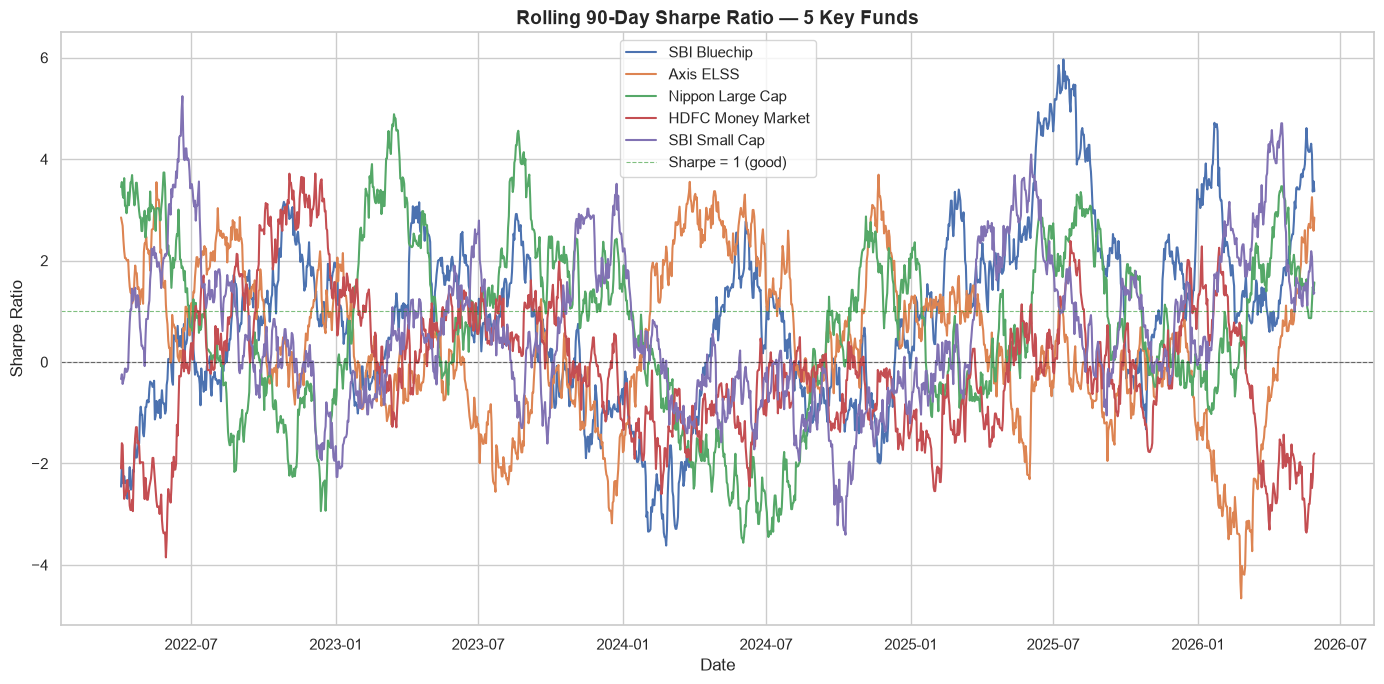

✅ Chart saved!


In [6]:
# Task 2 — Rolling 90-day Sharpe Ratio

Rf_daily = 0.065 / 252

# Pick 5 key funds
key_funds = {
    119551: 'SBI Bluechip',
    120503: 'Axis ELSS',
    118632: 'Nippon Large Cap',
    119092: 'HDFC Money Market',
    125497: 'SBI Small Cap'
}

plt.figure(figsize=(14, 7))

for code, name in key_funds.items():
    fund_returns = nav[nav['amfi_code'] == code].sort_values('date').set_index('date')['daily_return']
    
    # Rolling 90-day Sharpe
    rolling_sharpe = (
        (fund_returns - Rf_daily).rolling(90).mean() /
        fund_returns.rolling(90).std()
    ) * np.sqrt(252)
    
    plt.plot(rolling_sharpe.index, rolling_sharpe.values, label=name, linewidth=1.5)

plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
plt.axhline(y=1, color='green', linestyle='--', linewidth=0.8, alpha=0.5, label='Sharpe = 1 (good)')
plt.title('Rolling 90-Day Sharpe Ratio — 5 Key Funds', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sharpe Ratio')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/charts/11_rolling_sharpe.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [7]:
# Task 3 — Investor Cohort Analysis

# Find first transaction year for each investor
cohort = transactions.groupby('investor_id')['transaction_date'].min().reset_index()
cohort['cohort_year'] = cohort['transaction_date'].dt.year
cohort.columns = ['investor_id', 'first_transaction', 'cohort_year']

# Merge back with transactions
txn_cohort = transactions.merge(cohort[['investor_id', 'cohort_year']], on='investor_id')

# SIP transactions only
sip_cohort = txn_cohort[txn_cohort['transaction_type'] == 'SIP']

# Compute metrics per cohort
cohort_stats = sip_cohort.groupby('cohort_year').agg(
    num_investors=('investor_id', 'nunique'),
    avg_sip_amount=('amount_inr', 'mean'),
    total_invested=('amount_inr', 'sum')
).reset_index()

cohort_stats['avg_sip_amount'] = cohort_stats['avg_sip_amount'].round(0)
cohort_stats['total_invested'] = (cohort_stats['total_invested'] / 1e7).round(2)

print("Investor Cohort Analysis:")
print(cohort_stats)

# Top fund preference per cohort
top_fund_per_cohort = txn_cohort.groupby(['cohort_year', 'amfi_code']).size().reset_index(name='count')
top_fund_per_cohort = top_fund_per_cohort.sort_values('count', ascending=False).groupby('cohort_year').first().reset_index()
top_fund_per_cohort = top_fund_per_cohort.merge(funds[['amfi_code', 'scheme_name']], on='amfi_code')
print("\nTop Fund Preference per Cohort:")
print(top_fund_per_cohort[['cohort_year', 'scheme_name', 'count']])

Investor Cohort Analysis:
   cohort_year  num_investors  avg_sip_amount  total_invested
0         2024           4624         10997.0           21.50
1         2025            138         13505.0            0.23

Top Fund Preference per Cohort:
   cohort_year                                        scheme_name  count
0         2024  Mirae Asset Emerging Bluechip Fund - Regular -...    874
1         2025           ICICI Pru Liquid Fund - Regular - Growth     12


In [8]:
# Task 4 — SIP Continuity Analysis

# Filter SIP transactions only
sip_txns = transactions[transactions['transaction_type'] == 'SIP'].copy()
sip_txns = sip_txns.sort_values(['investor_id', 'transaction_date'])

# Only investors with 6+ SIP transactions
sip_count = sip_txns.groupby('investor_id').size()
active_investors = sip_count[sip_count >= 6].index
sip_active = sip_txns[sip_txns['investor_id'].isin(active_investors)].copy()

print(f"Investors with 6+ SIP transactions: {len(active_investors)}")

# Compute avg gap between transactions per investor
sip_active['prev_date'] = sip_active.groupby('investor_id')['transaction_date'].shift(1)
sip_active['gap_days'] = (sip_active['transaction_date'] - sip_active['prev_date']).dt.days

avg_gap = sip_active.groupby('investor_id')['gap_days'].mean().reset_index()
avg_gap.columns = ['investor_id', 'avg_gap_days']
avg_gap['avg_gap_days'] = avg_gap['avg_gap_days'].round(1)

# Flag at-risk investors (gap > 35 days)
avg_gap['status'] = avg_gap['avg_gap_days'].apply(
    lambda x: 'at-risk' if x > 35 else 'regular'
)

print("\nSIP Continuity Summary:")
print(avg_gap['status'].value_counts())
print(f"\nAverage gap across all investors: {avg_gap['avg_gap_days'].mean():.1f} days")
print("\nSample at-risk investors:")
print(avg_gap[avg_gap['status'] == 'at-risk'].head())

Investors with 6+ SIP transactions: 1362

SIP Continuity Summary:
status
at-risk    1332
regular      30
Name: count, dtype: int64

Average gap across all investors: 64.9 days

Sample at-risk investors:
  investor_id  avg_gap_days   status
0   INV000004          85.4  at-risk
1   INV000008          70.4  at-risk
2   INV000010          64.8  at-risk
3   INV000011          40.2  at-risk
4   INV000012          57.0  at-risk


In [9]:
# Task 5 — Simple Fund Recommender

def recommend_funds(risk_appetite):
    """
    Input: risk_appetite — 'Low', 'Moderate', or 'High'
    Output: Top 3 funds by Sharpe ratio within matching risk grade
    """
    # Map risk appetite to risk grades in fund master
    risk_map = {
        'Low': ['Low', 'Moderately Low'],
        'Moderate': ['Moderate', 'Moderately High'],
        'High': ['High', 'Very High']
    }
    
    valid_grades = risk_map.get(risk_appetite, [])
    
    # Filter funds by risk grade
    eligible_funds = funds[funds['risk_category'].isin(valid_grades)]
    
    # Merge with scorecard to get Sharpe ratio
    eligible_with_score = eligible_funds.merge(
        scorecard[['amfi_code', 'sharpe_ratio', 'cagr_3yr_pct', 'score']], 
        on='amfi_code'
    )
    
    # Top 3 by Sharpe ratio
    top3 = eligible_with_score.nlargest(3, 'sharpe_ratio')[
        ['scheme_name', 'fund_house', 'risk_category', 'sharpe_ratio', 'cagr_3yr_pct', 'score']
    ].reset_index(drop=True)
    
    print(f"\n🎯 Top 3 funds for {risk_appetite} risk appetite:")
    print(top3.to_string())
    return top3

# Test all three risk levels
recommend_funds('Low')
recommend_funds('Moderate')
recommend_funds('High')


🎯 Top 3 funds for Low risk appetite:
                                            scheme_name        fund_house risk_category  sharpe_ratio  cagr_3yr_pct  score
0          SBI Magnum Gilt Fund - Regular Plan - Growth   SBI Mutual Fund           Low        -0.743          5.80   27.2
1  Nippon India Gilt Securities Fund - Regular - Growth   Nippon India MF           Low        -0.851          3.78   27.9
2          HDFC Short Term Debt Fund - Regular - Growth  HDFC Mutual Fund           Low        -1.040          3.83   25.6

🎯 Top 3 funds for Moderate risk appetite:
                                     scheme_name         fund_house    risk_category  sharpe_ratio  cagr_3yr_pct  score
0  Mirae Asset Large Cap Fund - Regular - Growth     Mirae Asset MF         Moderate         1.068         33.95   80.0
1         Kotak Flexicap Fund - Regular - Growth  Kotak Mahindra MF  Moderately High         0.966         29.69   78.2
2      SBI Bluechip Fund - Regular Plan - Growth    SBI Mutual Fund

,scheme_name,fund_house,risk_category,sharpe_ratio,cagr_3yr_pct,score
0,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,High,0.919,28.48,73.2
1,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,High,0.883,31.22,85.1
2,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,High,0.833,26.85,67.1


In [10]:
# Save recommender as recommender.py
recommender_code = '''import pandas as pd

# Load data
funds = pd.read_csv('../data/processed/01_fund_master_clean.csv')
scorecard = pd.read_csv('../data/processed/fund_scorecard.csv')

def recommend_funds(risk_appetite):
    """
    Input: risk_appetite — Low, Moderate, or High
    Output: Top 3 funds by Sharpe ratio within matching risk grade
    """
    risk_map = {
        "Low": ["Low", "Moderately Low"],
        "Moderate": ["Moderate", "Moderately High"],
        "High": ["High", "Very High"]
    }
    
    valid_grades = risk_map.get(risk_appetite, [])
    eligible_funds = funds[funds["risk_category"].isin(valid_grades)]
    eligible_with_score = eligible_funds.merge(
        scorecard[["amfi_code", "sharpe_ratio", "cagr_3yr_pct", "score"]], 
        on="amfi_code"
    )
    top3 = eligible_with_score.nlargest(3, "sharpe_ratio")[
        ["scheme_name", "fund_house", "risk_category", "sharpe_ratio", "cagr_3yr_pct", "score"]
    ].reset_index(drop=True)
    
    print(f"Top 3 funds for {risk_appetite} risk appetite:")
    print(top3.to_string())
    return top3

if __name__ == "__main__":
    for risk in ["Low", "Moderate", "High"]:
        recommend_funds(risk)
        print()
'''

with open('../recommender.py', 'w') as f:
    f.write(recommender_code)

print("✅ Saved recommender.py")

✅ Saved recommender.py


Sector Concentration (HHI) — Most Concentrated Funds:
                                          scheme_name      hhi  num_sectors
19              Axis Bluechip Fund - Regular - Growth  2968.28            7
30      Mirae Asset Tax Saver Fund - Regular - Growth  2550.94            7
7   HDFC Mid-Cap Opportunities Fund - Direct - Growth  2531.55            6
27              UTI Flexi Cap Fund - Regular - Growth  2513.32            6
32                 DSP Midcap Fund - Regular - Growth  2410.77            7
10           ICICI Pru Midcap Fund - Regular - Growth  2386.00            7
15                     Nippon India ETF Nifty 50 BeES  2375.44            6
3           SBI Small Cap Fund - Direct Plan - Growth  2323.61            7
11  ICICI Pru Value Discovery Fund - Regular - Growth  2313.72            7
6   HDFC Mid-Cap Opportunities Fund - Regular - Gr...  2276.47            7


C:\Users\samya\AppData\Local\Temp\ipykernel_45288\3510550970.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_hhi, x='hhi', y='scheme_name', palette='Reds_r')


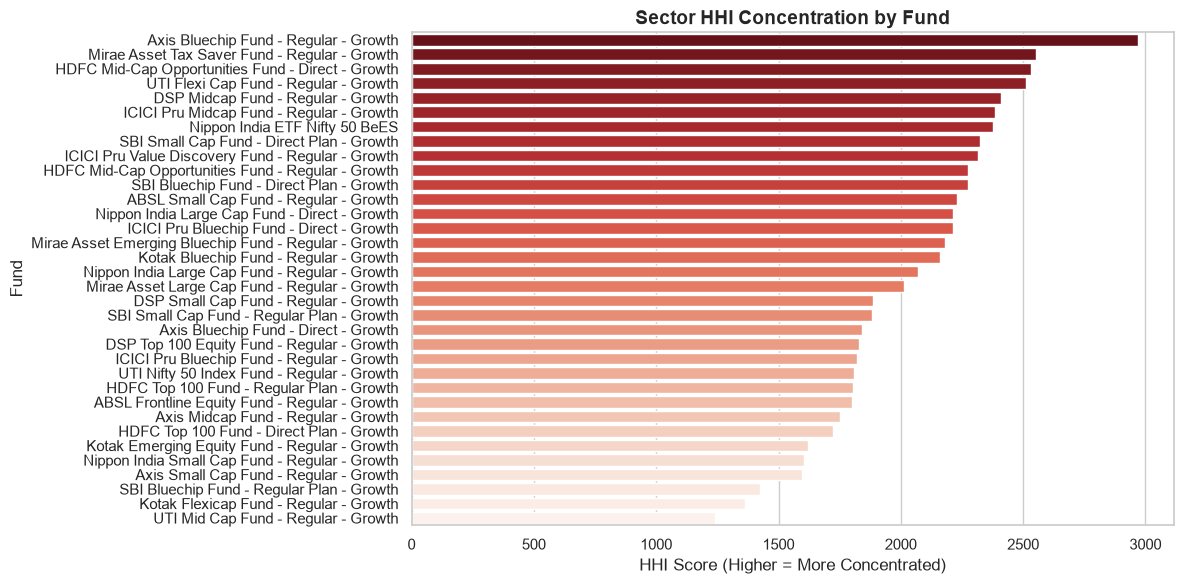

✅ Chart saved!


In [11]:
# Task 6 — Sector HHI Concentration

# HHI = sum of squared weights per fund
# Higher HHI = more concentrated portfolio = higher sector risk

hhi_results = []

for code in portfolio['amfi_code'].unique():
    fund_portfolio = portfolio[portfolio['amfi_code'] == code]
    
    # Get sector weights
    sector_weights = fund_portfolio.groupby('sector')['weight_pct'].sum()
    
    # Normalise to percentage (should sum to ~100)
    sector_weights_pct = sector_weights / sector_weights.sum() * 100
    
    # HHI = sum of squared weights
    hhi = (sector_weights_pct ** 2).sum()
    
    hhi_results.append({
        'amfi_code': code,
        'hhi': round(hhi, 2),
        'num_sectors': len(sector_weights)
    })

df_hhi = pd.DataFrame(hhi_results)
df_hhi = df_hhi.merge(funds[['amfi_code', 'scheme_name', 'category']], on='amfi_code')
df_hhi = df_hhi.sort_values('hhi', ascending=False)

print("Sector Concentration (HHI) — Most Concentrated Funds:")
print(df_hhi[['scheme_name', 'hhi', 'num_sectors']].head(10))

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=df_hhi, x='hhi', y='scheme_name', palette='Reds_r')
plt.title('Sector HHI Concentration by Fund', fontsize=14, fontweight='bold')
plt.xlabel('HHI Score (Higher = More Concentrated)')
plt.ylabel('Fund')
plt.tight_layout()
plt.savefig('../reports/charts/12_sector_hhi.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

## Advanced Analytics — Key Findings

1. **Small Cap funds carry the highest risk** — ABSL Small Cap has a 95% VaR of -2.39%, 
meaning on bad days investors can expect to lose at least 2.39% of their investment. 
CVaR of -3.03% confirms losses can be severe on extreme days.

2. **Risk-adjusted performance is highly time-dependent** — Rolling 90-day Sharpe ratios 
fluctuate between -4 and +6 for all funds, confirming that no fund delivers consistently 
superior risk-adjusted returns across all market conditions.

3. **Newer investors (2025 cohort) invest more per SIP** — Average SIP amount of ₹13,505 
vs ₹10,997 for 2024 cohort, suggesting growing financial confidence among recent investors.

4. **SIP continuity is critically low** — 97.8% of investors with 6+ SIP transactions have 
average gaps exceeding 35 days (avg 64.9 days), indicating widespread irregular payment 
patterns that require immediate business intervention.

5. **Axis Bluechip has the most concentrated sector portfolio** — HHI of ~3000 vs UTI Mid 
Cap's ~1300, meaning Axis Bluechip carries significantly higher sector concentration risk 
despite being a large cap fund.